In [1]:
import os

base_path = "/kaggle/input/jan-2026-dl-gen-ai-project"

for root, dirs, files in os.walk(base_path):
    print(root)
    break  

# Setup

In [2]:
!pip install librosa -q

!pip install wandb -q

# Imports

In [3]:
import os
import torch
import librosa
import librosa.display
from torch.utils.data import Dataset, DataLoader, Subset
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
from torch import nn, optim
import wandb
from sklearn.metrics import f1_score
from tqdm import tqdm
from transformers import Wav2Vec2ForSequenceClassification, Wav2Vec2FeatureExtractor

c:\Users\saket\Desktop\DL_Gen_AI\DLGenAI_Project-Messy_Mashup\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
DATA_PATH = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems"

# Weights & Biases Login

In [5]:
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()

os.environ["WANDB_API_KEY"] = user_secrets.get_secret("wandb")

wandb.login()

ModuleNotFoundError: No module named 'kaggle_secrets'

# Visualizing librosa image

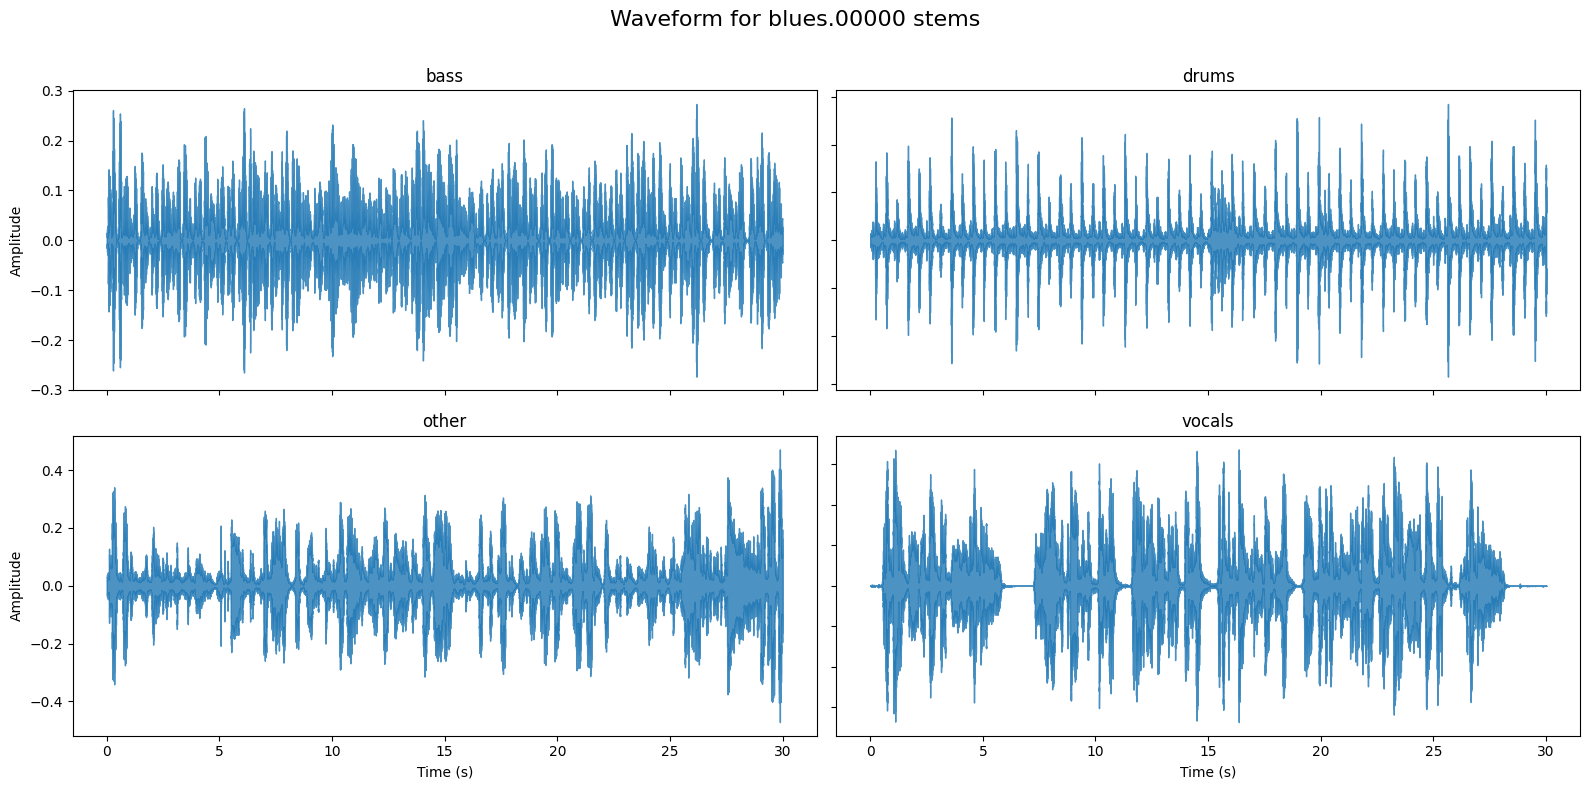

In [ ]:
base = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems/blues/blues.00000"

files = ["bass.wav", "drums.wav", "other.wav", "vocals.wav"]

plt.figure(figsize=(16, 8))
for i, fn in enumerate(files, start=1):
    path = os.path.join(base, fn)
    y, sr = librosa.load(path, sr=None, mono=True)
    
    ax = plt.subplot(2, 2, i)
    librosa.display.waveshow(y, sr=sr, alpha=0.8)
    ax.set_title(fn.replace(".wav", ""))
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")
    ax.label_outer()

plt.suptitle("Waveform for blues.00000 stems", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

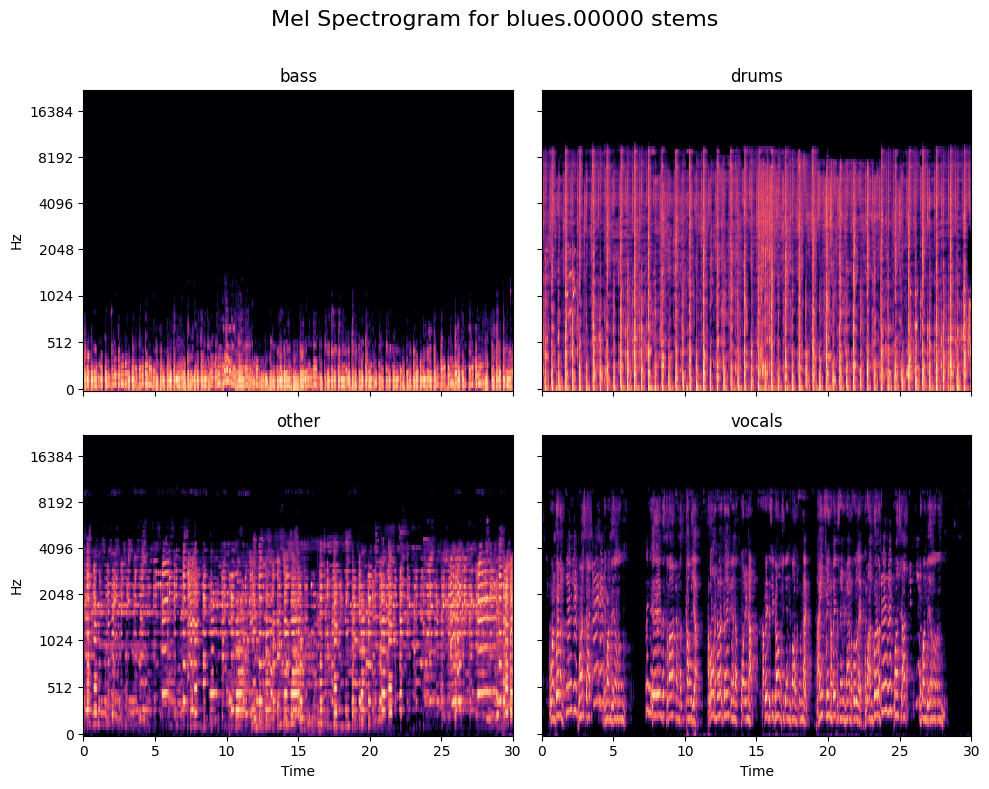

In [ ]:
base = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems/blues/blues.00000"
files = ["bass.wav", "drums.wav", "other.wav", "vocals.wav"]

plt.figure(figsize=(10, 8))
for i, fn in enumerate(files, start=1):
    path = os.path.join(base, fn)
    y, sr = librosa.load(path, sr=None, mono=True)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    
    ax = plt.subplot(2, 2, i)
    librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel', cmap='magma')
    ax.set_title(fn.replace(".wav", ""))
    ax.label_outer()

plt.suptitle("Mel Spectrogram for blues.00000 stems", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [ ]:
print(mel)

[[2.2040933e-05 5.4889591e-05 9.1858514e-05 ... 3.1235732e-06
  7.1692943e-06 8.1868138e-06]
 [3.1041216e-06 4.7972020e-07 2.1619556e-07 ... 1.2369833e-07
  3.2203621e-07 1.5492146e-06]
 [8.3106681e-07 2.4323319e-07 1.1142313e-08 ... 1.2728332e-08
  2.6132273e-08 2.8358352e-07]
 ...
 [2.0589344e-09 2.8151874e-09 1.8739115e-09 ... 2.4342719e-09
  2.7560669e-09 4.4028412e-09]
 [2.0390079e-09 2.2109750e-09 1.8361507e-09 ... 2.1192696e-09
  2.4015614e-09 1.9271029e-09]
 [1.7419396e-09 1.9627082e-09 1.7010054e-09 ... 2.5131277e-09
  3.0851073e-09 1.7013105e-09]]


# Mel dB in Normalized Array

In [ ]:
mel_db = librosa.power_to_db(mel)
print(mel_db)

[[-46.016014 -42.605103 -40.36881  ... -46.016014 -46.016014 -46.016014]
 [-46.016014 -46.016014 -46.016014 ... -46.016014 -46.016014 -46.016014]
 [-46.016014 -46.016014 -46.016014 ... -46.016014 -46.016014 -46.016014]
 ...
 [-46.016014 -46.016014 -46.016014 ... -46.016014 -46.016014 -46.016014]
 [-46.016014 -46.016014 -46.016014 ... -46.016014 -46.016014 -46.016014]
 [-46.016014 -46.016014 -46.016014 ... -46.016014 -46.016014 -46.016014]]


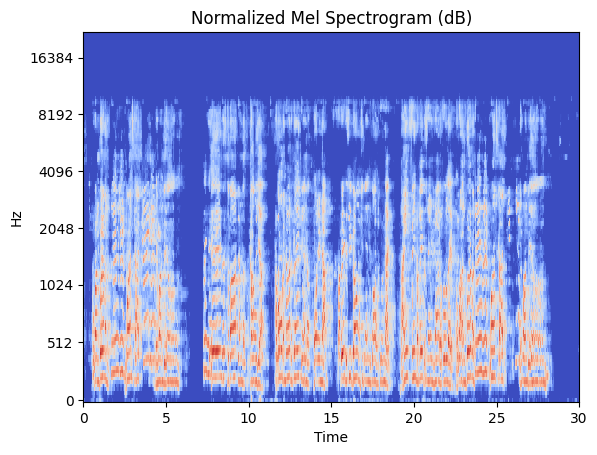

In [ ]:
mel_db = librosa.power_to_db(mel, ref=np.max)
mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-6) 

librosa.display.specshow(
    mel_db,
    sr=sr,
    x_axis="time",
    y_axis="mel"
)
plt.title("Normalized Mel Spectrogram (dB)")
plt.show()

# DataLoader

# CNN-LSTM Model

### Extract mel-spectrograms and labels from the dataset

In [ ]:
import random

def augment_audio(audio, sr=22050):
   
    noise = np.random.randn(len(audio)) * random.uniform(0.001, 0.015)
    audio = audio + noise

    
    audio = audio * random.uniform(0.6, 1.4)

   
    rate = random.uniform(0.85, 1.15)
    audio = librosa.effects.time_stretch(audio, rate=rate)

   
    steps = random.randint(-2, 2)
    audio = librosa.effects.pitch_shift(audio, sr=sr, n_steps=steps)

    return audio


def extract_features_augmented(data_path, n_mels=128, hop_length=512, 
                                num_segments=10, augment=True, aug_copies=2):
    X, y = [], []
    sample_rate = 22050
    samples_per_track = sample_rate * 30
    samples_per_segment = int(samples_per_track / num_segments)

    genres = 'blues classical country disco hiphop jazz metal pop reggae rock'.split()

    for label_idx, genre in enumerate(genres):
        genre_folder = os.path.join(data_path, genre)
        print(f"Processing genre: {genre}")
        for track in os.listdir(genre_folder):
            track_path = os.path.join(genre_folder, track)
            if not os.path.isdir(track_path): continue

            
            mixed_audio = None
            for stem_file in ["bass.wav", "drums.wav", "other.wav", "vocals.wav"]:
                file_path = os.path.join(track_path, stem_file)
                if not os.path.exists(file_path): continue
                try:
                    audio, _ = librosa.load(file_path, sr=sample_rate, mono=True)
                    if len(audio) < samples_per_track:
                        audio = np.pad(audio, (0, samples_per_track - len(audio)))
                    else:
                        audio = audio[:samples_per_track]
                    mixed_audio = audio if mixed_audio is None else mixed_audio + audio
                except:
                    continue

            if mixed_audio is None: continue

            
            mixed_audio = mixed_audio / (np.max(np.abs(mixed_audio)) + 1e-6)

           
            versions = [mixed_audio]
            if augment:
                for _ in range(aug_copies):
                    try:
                        versions.append(augment_audio(mixed_audio.copy(), sr=sample_rate))
                    except:
                        pass

            for audio_ver in versions:
                if len(audio_ver) < samples_per_track:
                    audio_ver = np.pad(audio_ver, (0, samples_per_track - len(audio_ver)))

                for d in range(num_segments):
                    start  = samples_per_segment * d
                    finish = start + samples_per_segment
                    mel    = librosa.feature.melspectrogram(
                                y=audio_ver[start:finish], sr=sample_rate,
                                n_mels=n_mels, hop_length=hop_length)
                    mel_db = librosa.power_to_db(mel, ref=np.max)
                    if mel_db.shape[1] == int(np.ceil(samples_per_segment / hop_length)):
                        X.append(mel_db.T)
                        y.append(label_idx)

    return np.array(X), np.array(y)

### Train-Test Split

In [ ]:
X, y = extract_features_augmented(DATA_PATH)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)


Processing genre: blues
Processing genre: classical
Processing genre: country
Processing genre: disco
Processing genre: hiphop
Processing genre: jazz
Processing genre: metal
Processing genre: pop
Processing genre: reggae
Processing genre: rock


### DataLoaders for Train, Val, Test

In [ ]:
def to_tensor(X, y):
    return TensorDataset(torch.FloatTensor(X), torch.LongTensor(y))

train_loader = DataLoader(to_tensor(X_train, y_train),
                           batch_size=32, shuffle=True, 
                           num_workers = 2, pin_memory = True)

val_loader = DataLoader(to_tensor(X_val, y_val),
                         batch_size=16, shuffle=False,
                         num_workers= 2, pin_memory= True)

test_loader = DataLoader(to_tensor(X_test, y_test),
                          batch_size=16, shuffle=False,
                          num_workers= 2, pin_memory= True)

### Model Class

In [ ]:
class CNNLSTM(nn.Module):
    def __init__(self, num_classes=10):
        super(CNNLSTM, self).__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.1),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.1),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 128, 3, padding=1),  # extra conv layer
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((None, 16))    # fix the freq dim to 16
        )

        self.lstm = nn.LSTM(input_size=128 * 16,
                            hidden_size=256,        # bigger hidden
                            num_layers=2,
                            batch_first=True,
                            dropout=0.3,
                            bidirectional=True)     # bidirectional helps

        self.classifier = nn.Sequential(
            nn.Linear(256 * 2, 128),               # *2 for bidirectional
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.cnn(x)
        B, C, T_p, F_p = x.shape
        x = x.permute(0, 2, 1, 3).contiguous()
        x = x.view(B, T_p, -1)
        _, (hn, _) = self.lstm(x)
        # concat last layer forward + backward
        out = torch.cat([hn[-2], hn[-1]], dim=1)
        return self.classifier(out)

In [ ]:
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())
print("Torch version:", torch.__version__)
print("CUDA version (torch):", torch.version.cuda)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

### Initializing Model, Loss Function, and Optimizer

In [ ]:
import torch.optim as optim

model = CNNLSTM().to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=50, eta_min=1e-6           
)

### Initializing Weights & Biases

In [ ]:
import wandb

wandb.init(
    project="22f1001220-t12026",
    name="Cnn_model",
    config={
        "epochs":50,
        "batch_size":32,
        "lr":0.0001
    }
)
wandb.watch(model, log="all")


In [ ]:
print("X shape:", X.shape)
print("NaN in X:", np.isnan(X).any())
print("Inf in X:", np.isinf(X).any())
print("y dtype:", y.dtype)

### Training loop

In [ ]:
history = {"train_loss": [], "val_loss": [], "train_acc": [], "f1_score": [], "val_acc": []}

epochs = 50

for epoch in range(epochs):
    #Train
    model.train()
    train_loss, train_correct = 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_correct += (outputs.argmax(1) == labels).sum().item()

    
    #Validation
    model.eval()
    all_preds = []
    all_labels = []
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)

            val_loss += criterion(outputs, labels).item()
            val_correct += (outputs.argmax(1) == labels).sum().item()

            pred = torch.argmax(outputs, dim=1)

            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

        f1 = f1_score(all_labels, all_preds, average='macro')
    
    history["train_loss"].append(train_loss / len(train_loader))
    history["val_loss"].append(val_loss / len(val_loader))
    history["train_acc"].append(train_correct/len(X_train))
    history["f1_score"].append(f1)
    history["val_acc"].append(val_correct/len(X_val))
    

    learning_rate = optimizer.param_groups[0]['lr']

    #wandb log

    wandb.log({
        "epoch": epoch,
        "train_loss": history["train_loss"][-1],
        "val_loss": history["val_loss"][-1],
        "f1_score": history["f1_score"][-1],
        "train_acc": history["train_acc"][-1],
        "val_acc": history["val_acc"][-1],

        "learning_rate": learning_rate
    })

    scheduler.step()

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {history['train_loss'][-1]:.4f} |\
    Train Acc: {history['train_acc'][-1]:.4f} |\
    f1 Score: {history['f1_score'][-1]:.4f} |\
    Val Loss: {history['val_loss'][-1]:.4f} |\
    Val Acc: {history['val_acc'][-1]:.4f}")

        


In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.legend(); plt.title("Loss")

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.legend(); plt.title("Accuracy")
plt.show()

In [ ]:
wandb.finish()

# Fine-Tuned Wav2Vec2 Model

In [ ]:
# MODEL_NAME = "facebook/wav2vec2-base"

# feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(MODEL_NAME)

# model_transformer = Wav2Vec2ForSequenceClassification.from_pretrained(
#     MODEL_NAME,
#     num_labels=10,
#     ignore_mismatched_sizes=True
# )

# for param in model_transformer.wav2vec2.parameters():
#     param.requires_grad = False


# for param in model_transformer.classifier.parameters():
#     param.requires_grad = True

# model_transformer = model_transformer.to(device)

# optimizer_t = torch.optim.Adam(
#     filter(lambda p: p.requires_grad, model_transformer.parameters()),
#     lr=1e-4
# )

### Dataset for raw waveform

In [ ]:

# class WaveformDataset(Dataset):
#     def __init__(self, data_path, sr=16000, duration=3, num_segments=10):
#         self.sr               = sr          
#         self.samples_per_seg  = sr * duration
#         self.samples_per_track = sr * 30
#         self.num_segments     = num_segments
#         self.X = []
#         self.y = []
#         genres = 'blues classical country disco hiphop jazz metal pop reggae rock'.split()

#         for label_idx, genre in enumerate(genres):
#             genre_folder = os.path.join(data_path, genre)
#             print(f"Processing: {genre}")
#             for track in os.listdir(genre_folder):
#                 track_path = os.path.join(genre_folder, track)
#                 if not os.path.isdir(track_path): continue
#                 for stem_file in os.listdir(track_path):
#                     if not stem_file.endswith(".wav"): continue
#                     file_path = os.path.join(track_path, stem_file)
#                     try:
#                         audio, _ = librosa.load(file_path, sr=sr, mono=True)
#                         if len(audio) < self.samples_per_track:
#                             audio = np.pad(audio, (0, self.samples_per_track - len(audio)))
#                         for d in range(num_segments):
#                             start  = self.samples_per_seg * d
#                             finish = start + self.samples_per_seg
#                             self.X.append(audio[start:finish])
#                             self.y.append(label_idx)
#                     except:
#                         continue

#         self.X = np.array(self.X, dtype=np.float32)
#         self.y = np.array(self.y)

#     def __len__(self): return len(self.X)
#     def __getitem__(self, i):
#         return torch.tensor(self.X[i]), torch.tensor(self.y[i], dtype=torch.long)

In [ ]:

# wave_dataset = WaveformDataset(DATA_PATH)

# indices = list(range(len(wave_dataset)))
# train_idx, val_idx = train_test_split(
#     indices, test_size=0.2, random_state=42, stratify=wave_dataset.y
# )

# wave_train_loader = DataLoader(
#     Subset(wave_dataset, train_idx), batch_size=16, shuffle=True, num_workers=2
# )
# wave_val_loader = DataLoader(
#     Subset(wave_dataset, val_idx), batch_size=16, shuffle=False, num_workers=2
# )

# # Train
# history_transformer = train_transformer(
#     model_transformer, wave_train_loader, optimizer_t, epochs=10
# )

In [ ]:
# wandb.init(
#     project="22f1001220-t12026",
#     name="wav2vec2_transformer",
#     config={
#         "epochs": 10,
#         "batch_size": 16,
#         "lr": 1e-4,
#         "model": "facebook/wav2vec2-base",
#         "frozen_backbone": True
#     }
# )
# wandb.watch(model_transformer, log="all")

In [ ]:
# def train_transformer(model, train_loader, val_loader, optimizer, epochs=10):
#     history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "f1_score": []}

#     for epoch in range(epochs):
#         # ── Train ──
#         model.train()
#         total_loss, train_correct = 0, 0

#         loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=True)
#         for waveforms, labels in loop:
#             waveforms, labels = waveforms.to(device), labels.to(device)
#             optimizer.zero_grad()
#             outputs = model(input_values=waveforms, labels=labels)
#             loss    = outputs.loss
#             loss.backward()
#             optimizer.step()

#             total_loss    += loss.item()
#             train_correct += (torch.argmax(outputs.logits, dim=1) == labels).sum().item()
#             loop.set_postfix(loss=f"{loss.item():.4f}")

#         # ── Validation ──
#         model.eval()
#         val_loss, val_correct = 0, 0
#         all_preds, all_labels = [], []

#         with torch.no_grad():
#             for waveforms, labels in val_loader:
#                 waveforms, labels = waveforms.to(device), labels.to(device)
#                 outputs = model(input_values=waveforms, labels=labels)

#                 val_loss    += outputs.loss.item()
#                 val_correct += (torch.argmax(outputs.logits, dim=1) == labels).sum().item()
#                 all_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
#                 all_labels.extend(labels.cpu().numpy())

#         f1 = f1_score(all_labels, all_preds, average='macro')

#         # ── History ──
#         history["train_loss"].append(total_loss / len(train_loader))
#         history["val_loss"].append(val_loss   / len(val_loader))
#         history["train_acc"].append(train_correct / len(train_idx))
#         history["val_acc"].append(val_correct   / len(val_idx))
#         history["f1_score"].append(f1)

#         lr = optimizer.param_groups[0]['lr']

#         # ── WandB log ──
#         wandb.log({
#             "epoch":      epoch,
#             "train_loss": history["train_loss"][-1],
#             "val_loss":   history["val_loss"][-1],
#             "train_acc":  history["train_acc"][-1],
#             "val_acc":    history["val_acc"][-1],
#             "f1_score":   history["f1_score"][-1],
#             "learning_rate": lr
#         })

#         print(f"Epoch {epoch+1}/{epochs} | "
#               f"Train Loss: {history['train_loss'][-1]:.4f} | "
#               f"Train Acc: {history['train_acc'][-1]:.4f} | "
#               f"Val Loss: {history['val_loss'][-1]:.4f} | "
#               f"Val Acc: {history['val_acc'][-1]:.4f} | "
#               f"F1: {history['f1_score'][-1]:.4f}")

#     wandb.finish()
#     return history


# history_transformer = train_transformer(
#     model_transformer, wave_train_loader, wave_val_loader, optimizer_t, epochs=10
# )

#  RNN: Simple Bidirectional GRU

In [ ]:
class BiGRUClassifier(nn.Module):
    def __init__(self, input_size=128, hidden_size=64, num_layers=2, num_classes=10):
        super(BiGRUClassifier, self).__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,     
            dropout=0.3
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),   
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # x: (B, time, n_mels=128)
        _, hn = self.gru(x)        
        
        forward_h  = hn[-2]      
        backward_h = hn[-1]        
        out = torch.cat([forward_h, backward_h], dim=1)  
        return self.classifier(out)


model_gru = BiGRUClassifier().to(device)
optimizer_gru = torch.optim.Adam(model_gru.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_gru = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_gru, mode='min', factor=0.5, patience=3
)

#### WandB init for BiGRU

In [ ]:
wandb.init(
    project="22f1001220-t12026",
    name="BiGRU_model",
    config={
        "epochs": 30,
        "batch_size": 32,
        "lr": 1e-3,
        "hidden_size": 64,
        "num_layers": 2,
        "dropout": 0.3,
        "weight_decay": 1e-4
    }
)
wandb.watch(model_gru, log="all")

### Training Loop

In [ ]:
history_gru = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "f1_score": []}
epochs = 30

for epoch in range(epochs):
    # train
    model_gru.train()
    train_loss, train_correct = 0, 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=True)
    for inputs, labels in loop:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer_gru.zero_grad()
        outputs = model_gru(inputs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer_gru.step()
        train_loss    += loss.item()
        train_correct += (outputs.argmax(1) == labels).sum().item()
        loop.set_postfix(loss=f"{loss.item():.4f}")

    # validation
    model_gru.eval()
    val_loss, val_correct = 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_gru(inputs)
            val_loss    += criterion(outputs, labels).item()
            val_correct += (outputs.argmax(1) == labels).sum().item()
            all_preds.extend(outputs.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    f1 = f1_score(all_labels, all_preds, average='macro')
    scheduler_gru.step(val_loss / len(val_loader))

    history_gru["train_loss"].append(train_loss / len(train_loader))
    history_gru["val_loss"].append(val_loss   / len(val_loader))
    history_gru["train_acc"].append(train_correct / len(X_train))
    history_gru["val_acc"].append(val_correct   / len(X_val))
    history_gru["f1_score"].append(f1)

    lr = optimizer_gru.param_groups[0]['lr']

    # ── WandB log ──
    wandb.log({
        "epoch":      epoch,
        "train_loss": history_gru["train_loss"][-1],
        "val_loss":   history_gru["val_loss"][-1],
        "train_acc":  history_gru["train_acc"][-1],
        "val_acc":    history_gru["val_acc"][-1],
        "f1_score":   history_gru["f1_score"][-1],
        "learning_rate": lr
    })

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {history_gru['train_loss'][-1]:.4f} | "
          f"Train Acc: {history_gru['train_acc'][-1]:.4f} | "
          f"Val Loss: {history_gru['val_loss'][-1]:.4f} | "
          f"Val Acc: {history_gru['val_acc'][-1]:.4f} | "
          f"F1: {f1:.4f}")


In [ ]:
wandb.finish()

# Evaluation

In [ ]:
TEST_DATA_PATH = r"C:\Users\saket\Desktop\DL_Gen_AI\DLGenAI_Project-Messy_Mashup\data\messy_mashup\mashups"
TEST_CSV_PATH  = r"C:\Users\saket\Desktop\DL_Gen_AI\DLGenAI_Project-Messy_Mashup\data\messy_mashup\test.csv"

In [ ]:
sr               = 22050
n_mels           = 128
hop_length       = 512
num_segments     = 10
samples_per_track   = sr * 30
samples_per_segment = int(samples_per_track / num_segments)

df = pd.read_csv(TEST_CSV_PATH)
file_ids  = df["id"].tolist()
filenames = df["filename"].tolist()

X_test_list = []   
id_list     = []  

for fid, fname in tqdm(zip(file_ids, filenames), total=len(file_ids)):
    path = os.path.join(TEST_DATA_PATH, os.path.basename(fname))
    try:
        audio, _ = librosa.load(path, sr=sr, mono=True)

        if len(audio) < samples_per_track:
            audio = np.pad(audio, (0, samples_per_track - len(audio)))

        for d in range(num_segments):
            start  = samples_per_segment * d
            finish = start + samples_per_segment

            mel    = librosa.feature.melspectrogram(
                         y=audio[start:finish], sr=sr,
                         n_mels=n_mels, hop_length=hop_length)
            mel_db = librosa.power_to_db(mel, ref=np.max)

            if mel_db.shape[1] == int(np.ceil(samples_per_segment / hop_length)):
                X_test_list.append(mel_db.T)   
                id_list.append(fid)

    except Exception as e:
        print(f"Skipped {fname}: {e}")
        continue

X_test_arr = np.array(X_test_list) 
X_test_tensor = torch.FloatTensor(X_test_arr)
print(f"Extracted {len(X_test_arr)} segments from {len(file_ids)} files")

In [ ]:

from collections import Counter, defaultdict

IDX_TO_GENRE = {
    0: "blues", 1: "classical", 2: "country", 3: "disco", 4: "hiphop",
    5: "jazz",  6: "metal",     7: "pop",     8: "reggae", 9: "rock"
}

def create_submission(model, model_name="model", batch_size=64):
    model.eval()
    all_preds = []

    with torch.no_grad():
        for i in range(0, len(X_test_tensor), batch_size):
            batch  = X_test_tensor[i:i+batch_size].to(device)
            output = model(batch)
            preds  = torch.argmax(output, dim=1)
            all_preds.extend(preds.cpu().numpy())

   
    votes = defaultdict(list)
    for fid, pred in zip(id_list, all_preds):
        votes[fid].append(pred)

    final_ids, final_genres = [], []
    for fid in file_ids:                         
        pred_idx = Counter(votes[fid]).most_common(1)[0][0]
        final_ids.append(fid)
        final_genres.append(IDX_TO_GENRE[pred_idx])

    submission = pd.DataFrame({"id": final_ids, "genre": final_genres})
    filename   = f"submission_{model_name}.csv"
    submission.to_csv(filename, index=False)

    print(f"Saved: {filename}  |  Shape: {submission.shape}")
    print(f"\nGenre distribution:\n{submission['genre'].value_counts()}")
    return submission

In [ ]:
# def create_submission_wav2vec(model, model_name="wav2vec2", sr=16000, duration=3, batch_size=8):
#     model.eval()
#     all_preds = []
    
   
#     X_wave_test = []
#     wave_id_list = []
#     samples_per_seg = sr * duration

#     for fid, fname in tqdm(zip(file_ids, filenames), total=len(file_ids)):
#         path = os.path.join(TEST_DATA_PATH, os.path.basename(fname))
#         try:
#             audio, _ = librosa.load(path, sr=sr, mono=True)
#             if len(audio) < sr * 30:
#                 audio = np.pad(audio, (0, sr * 30 - len(audio)))
#             for d in range(10):
#                 start  = samples_per_seg * d
#                 finish = start + samples_per_seg
#                 X_wave_test.append(audio[start:finish])
#                 wave_id_list.append(fid)
#         except Exception as e:
#             print(f"Skipped {fname}: {e}")

#     X_wave_tensor = torch.FloatTensor(np.array(X_wave_test, dtype=np.float32))

   
#     with torch.no_grad():
#         for i in range(0, len(X_wave_tensor), batch_size):
#             batch = X_wave_tensor[i:i+batch_size].to(device)
#             output = model(input_values=batch)        # <-- only difference from create_submission
#             preds  = torch.argmax(output.logits, dim=1)
#             all_preds.extend(preds.cpu().numpy())

  
#     votes = defaultdict(list)
#     for fid, pred in zip(wave_id_list, all_preds):
#         votes[fid].append(pred)

#     final_ids, final_genres = [], []
#     for fid in file_ids:
#         pred_idx = Counter(votes[fid]).most_common(1)[0][0]
#         final_ids.append(fid)
#         final_genres.append(IDX_TO_GENRE[pred_idx])

#     submission = pd.DataFrame({"id": final_ids, "genre": final_genres})
#     filename = f"submission_{model_name}.csv"
#     submission.to_csv(filename, index=False)
#     print(f"Saved: {filename}  |  Shape: {submission.shape}")
#     print(f"\nGenre distribution:\n{submission['genre'].value_counts()}")
#     return submission



# create_submission_wav2vec(model_transformer, model_name="wav2vec2")

In [ ]:

create_submission(model, model_name="CNNLSTM()")


In [ ]:

# from collections import Counter, defaultdict

# X_test_tensor = torch.FloatTensor(X_test_arr)   

# model.eval()
# all_preds = []
# batch_size = 64   

# with torch.no_grad():
#     for i in range(0, len(X_test_tensor), batch_size):
#         batch  = X_test_tensor[i:i+batch_size].to(device)
#         output = model(batch)
#         preds  = torch.argmax(output, dim=1)
#         all_preds.extend(preds.cpu().numpy())

# print(f"Inference done for {len(all_preds)} segments")

In [ ]:

# IDX_TO_GENRE = {
#     0: "blues", 1: "classical", 2: "country", 3: "disco", 4: "hiphop",
#     5: "jazz",  6: "metal",     7: "pop",     8: "reggae", 9: "rock"
# }

# votes = defaultdict(list)
# for fid, pred in zip(id_list, all_preds):
#     votes[fid].append(pred)

# final_ids, final_genres = [], []
# for fid in file_ids:            
#     pred_idx = Counter(votes[fid]).most_common(1)[0][0]
#     final_ids.append(fid)
#     final_genres.append(IDX_TO_GENRE[pred_idx])

# print(f"Final predictions: {len(final_ids)} files")

In [ ]:

# submission = pd.DataFrame({"id": final_ids, "genre": final_genres})
# print(submission.head(10))
# print(f"\nGenre distribution:\n{submission['genre'].value_counts()}")

# submission.to_csv("submission.csv", index=False)
# print("\nsubmission.csv saved!")